In [1]:
import os
os.chdir("..")

import torch
from PIL import Image
from dotenv import load_dotenv
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score

from src.dataset.test_dataset import AIRecognitionDataset
from src.models.model_api import OpenSourceModel, HuggingFaceModel, APIProvider


In [2]:
load_dotenv()

True

In [3]:
# load subset
from torch import utils
from torch.utils.data import Subset, DataLoader
import random

def load_dataset(n_samples: int = 100) -> Subset:
    dataset = AIRecognitionDataset()
    all_indices = list(range(len(dataset)))
    random_indices = random.sample(all_indices, n_samples)
    subset = Subset(dataset, random_indices)

    print(f"Loaded {len(subset)} random samples.")
    img_path, label = subset[0]
    print(img_path, label)
    img = Image.open(img_path).convert('RGB')
    plt.imshow(img)
    plt.title(f"[EXAMPLE IMAGE] label: {label}")
    plt.axis('off')
    plt.show()
    
    return subset


In [ ]:
from src.models.api_providers import HiveAPIProvider, SightengineAPIProvider

def test_api_providers(dataset):
    local_models = [HiveAPIProvider(), SightengineAPIProvider()]

    test_len = len(dataset)
    for x in tqdm(dataset, desc="evaluation in progress...", total=test_len):
        img_path, label = x
        
        for model in local_models:
            print(f"RESULT FROM {model.__class__.__name__}")
            result = model.predict(img_path)
            print(f"result: {result}, true label: {label}")

In [4]:
from src.models.hf_models import (
    AIOrNotHfModel, SDXLDetectorHfModel, AIVSHumanImageDetectorHfModel, DafilabAIImageDetectorHfModel,
    HfModelOutput
)

def test_hf_models(dataset):
    local_models = [AIOrNotHfModel(), SDXLDetectorHfModel(), AIVSHumanImageDetectorHfModel(),  DafilabAIImageDetectorHfModel()]
    
    test_len = len(dataset)
    for x in tqdm(dataset, desc="evaluation in progress...", total=len(dataset)):
        img_path, label = x
        img = Image.open(img_path).convert('RGB')
        plt.imshow(img)
        plt.title(f"Image {x}")
        plt.axis('off')
        plt.show()
        
        for model in local_models:
            print(f"RESULT FROM {model.__class__.__name__}")
            result = model.predict(img, with_probs=True)
            print(f"result: {result}, true label: {label}")

/Users/hxi/.pyenv/versions/3.10.4/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loaded 1 random samples.
data/test/archive/fake-v2/22719.png fake


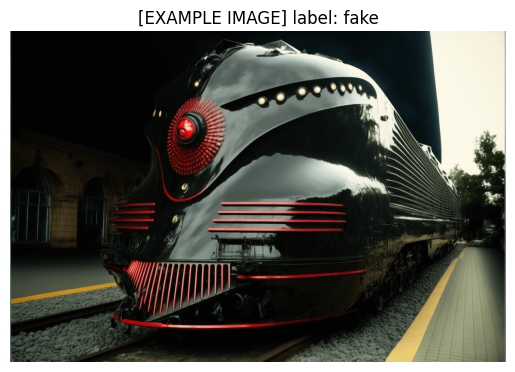

/Users/hxi/.pyenv/versions/3.10.4/lib/python3.10/site-packages/transformers/models/vit/feature_extraction_vit.py:30: FutureWarning: The class ViTFeatureExtractor is deprecated and will be removed in version 5 of Transformers. Please use ViTImageProcessor instead.
  warnings.warn(
Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


[AIOrNotHfModel] Model initialization done.
[SDXLDetectorHfModel] Model initialization done.
Loading processor from: Ateeqq/ai-vs-human-image-detector
Loading model from: Ateeqq/ai-vs-human-image-detector
Model and processor loaded successfully.
[AIVSHumanImageDetectorHfModel] Model initialization done.
[DafilabAIImageDetectorHfModel] Model initialization done.


evaluation in progress...:   0%|          | 0/1 [00:00<?, ?it/s]

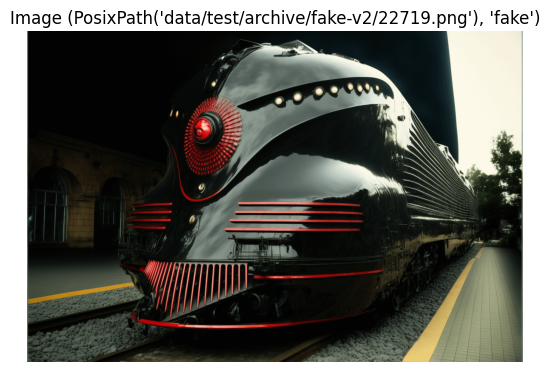

RESULT FROM AIOrNotHfModel
result: label='fake' probs=[0.0034926394000649452, 0.9965073466300964], true label: fake
RESULT FROM SDXLDetectorHfModel
result: label='fake' probs=[0.9977589845657349, 0.002241038717329502], true label: fake
RESULT FROM AIVSHumanImageDetectorHfModel
result: label='fake' probs=[0.9994114637374878, 0.0005885984282940626], true label: fake
RESULT FROM DafilabAIImageDetectorHfModel


evaluation in progress...: 100%|██████████| 1/1 [00:02<00:00,  2.54s/it]

result: label='fake' probs=[0.997218132019043, 0.002781840041279793], true label: fake


In [5]:
ds = load_dataset(n_samples=1)
test_hf_models(ds)

In [6]:
"""
    Thorough testing
"""
from collections import defaultdict
from pathlib import Path
import time

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, auc
)

from src.models.model_api import DiscriminatorModel

def evaluate(dataset: Subset, local_models: list[DiscriminatorModel]) -> tuple:
    y_true          = defaultdict(list)   # model_name -> [0/1, ...]
    y_pred          = defaultdict(list)   # model predictions
    y_prob          = defaultdict(list)   # probability of class 1 (“fake”)
    inference_times = defaultdict(list)   # seconds

    label2idx = {"real": 0, "fake": 1}   
    idx2label = {0: "real", 1: "fake"}
    model_names = [m.__class__.__name__ for m in local_models]
    total_len = len(dataset)

    for img_path, label in tqdm(dataset, desc="evaluating…", total=total_len):
        img   = Image.open(img_path).convert("RGB")
        label = label2idx[label]          # numeric ground-truth

        for i in range(len(local_models)):
            model = local_models[i]
            t0 = time.perf_counter()
            out = model.predict(img, with_probs=True)     # for now: HfModelOutput
            dt = time.perf_counter() - t0

            y_true[model_names[i]].append(label)
            y_pred[model_names[i]].append(label2idx[out.label])          # already 0/1
            y_prob[model_names[i]].append(out.probs if out.probs else None)                     # P(class==1)
            inference_times[model_names[i]].append(dt)
            
    return (
        y_true, y_pred, y_prob, inference_times, model_names
    )


def visualize_metrics(stats: tuple, local_models: list[DiscriminatorModel]) -> None:
    y_true, y_pred, y_prob, inference_times, model_names = stats

    # -------------------------  compute summary numbers -------------------------
    metrics = {"accuracy":   accuracy_score,
            "precision":  precision_score,
            "recall":     recall_score,
            "f1":         f1_score}

    summary = defaultdict(dict)   # summary[metric][model] -> value
    confmat = {}                  # confmat[model] -> (tn, fp, fn, tp)

    for i in range(len(local_models)):
        name    = model_names[i]
        y_t     = np.asarray(y_true[name])
        y_p     = np.asarray(y_pred[name])

        for metric_name, func in metrics.items():
            summary[name][metric_name] = func(y_t, y_p)

        tn, fp, fn, tp = confusion_matrix(y_t, y_p).ravel()
        confmat[name]  = (tn, fp, fn, tp)

    # -------------------------   bar-chart of accuracy / precision / recall / f1 -------------------------
    fig, ax = plt.subplots(layout='constrained', figsize=(8, 4.5))

    metric_order = ["accuracy", "precision", "recall", "f1"]   # 4 metrics
    n_models     = len(model_names)
    n_metrics    = len(metric_order)

    y = np.arange(n_models)          # one centre per model-row
    group_h = 0.8                    # total height of a row
    bar_h   = group_h / n_metrics    # thickness of a single bar

    for j, metric in enumerate(metric_order):
        # bar positions: offset each metric within the model-row
        offset  = (j - (n_metrics - 1) / 2) * bar_h
        widths  = [summary[m][metric] for m in model_names]   # metric values
        rects   = ax.barh(
            y + offset,               # y positions
            widths,                   # bar lengths (x-direction)
            bar_h,
            label=metric
        )
        # value labels at end of each bar
        ax.bar_label(rects, fmt="%.2f", padding=3, label_type="edge")

    # ---- cosmetics --------------------------------------------------------
    ax.set_xlabel("metric score")
    ax.set_xlim(0, 1.05)
    ax.set_yticks(y, model_names)
    ax.set_title("Classification metrics per model")
    ax.grid(axis="x", ls=":")

    # legend: vertical list on the right
    ax.legend(
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),   # just outside the axes
        ncols=1                       # => vertical
    )

    plt.show()

    # ----- confusion-matrix table even lower -----
    # fig, ax = plt.subplots(figsize=(6, 6))
    # cell_text = [[*confmat[m.name]] for m in local_models]
    # row_lbls  = [m.name for m in local_models]
    # col_lbls  = ["TN", "FP", "FN", "TP"]

    # table = plt.table(cellText=cell_text,
    #                   rowLabels=row_lbls,
    #                   colLabels=col_lbls,
    #                   cellLoc="center",
    #                   colLoc="center",
    #                   bbox=[0.0, -0.37, 1.0, 0.25])  # (x0, y0, width, height)

    # plt.subplots_adjust(left=0.08, right=0.98, bottom=0.35)  # leave room
    # plt.show()


    # ------------------------- ROC curves -------------------------
    fig, ax = plt.subplots(figsize=(6, 6))
    for name in model_names:
        fpr, tpr, _ = roc_curve(y_true[name], y_pred[name])
        ax.plot(fpr, tpr, label=f"{name} (AUC = {auc(fpr, tpr):.3f})")

    ax.plot([0, 1], [0, 1], ls="--")      # diagonal
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel("False-positive rate")
    ax.set_ylabel("True-positive rate")
    ax.set_title("ROC curves")
    ax.legend(loc="center left", frameon=False, bbox_to_anchor=(1.02, 0.5))
    plt.grid(ls=":")
    plt.show()

    # ------------------------- confusion matrices -------------------------
    n_models = len(local_models)
    fig, axes = plt.subplots(1, n_models, figsize=(4*n_models, 4))

    for ax, model in zip(np.atleast_1d(axes), local_models):
        name  = model.name
        cm    = np.asarray(confmat[name]).reshape(2, 2)

        im = ax.imshow(cm, interpolation="nearest")
        for i in range(2):
            for j in range(2):
                ax.text(j, i, cm[i, j], ha="center", va="center")

        ax.set_xticks([0, 1], ["Real", "Fake"])
        ax.set_yticks([0, 1], ["Real", "Fake"])
        ax.set_xlabel("Predicted")
        ax.set_ylabel("True")
        ax.set_title(name)

    fig.suptitle("Confusion matrices")
    plt.tight_layout()
    plt.show()

    # ------------------------- average inference time -------------------------
    avg_time = [np.mean(inference_times[m.name]) for m in local_models]

    x = np.arange(len(local_models))          # 0, 1, 2 …
    fig, ax = plt.subplots(figsize=(6, 4))

    # plot one bar per model and label it for the legend
    for i, (model, t) in enumerate(zip(local_models, avg_time)):
        ax.bar(x[i], t, width=0.6, label=model.__class__.__name__)

    # cosmetics ----------------------------------------------------------
    ax.set_ylabel("seconds / image")
    ax.set_title("Average per-image inference time")
    ax.set_xticks(x)                 # keep tick positions …
    ax.set_xticklabels([])           # … but hide the long names
    ax.grid(axis="y", ls=":")

    # legend centred below the bars
    ax.legend(loc="upper center",
            bbox_to_anchor=(0.5, -0.12),
            ncols=1,               # one column; change if >3 models
            frameon=False)

    plt.subplots_adjust(bottom=0.25) # leave room for the legend
    plt.show()

/Users/hxi/.pyenv/versions/3.10.4/lib/python3.10/site-packages/transformers/models/vit/feature_extraction_vit.py:30: FutureWarning: The class ViTFeatureExtractor is deprecated and will be removed in version 5 of Transformers. Please use ViTImageProcessor instead.
  warnings.warn(


[AIOrNotHfModel] Model initialization done.
Loaded 100 random samples.
data/test/archive/fake-v2/13466.png fake


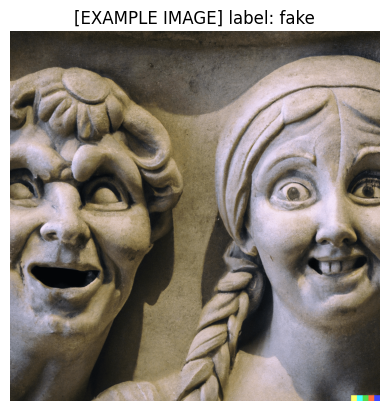

evaluating…: 100%|██████████| 100/100 [00:10<00:00,  9.44it/s]


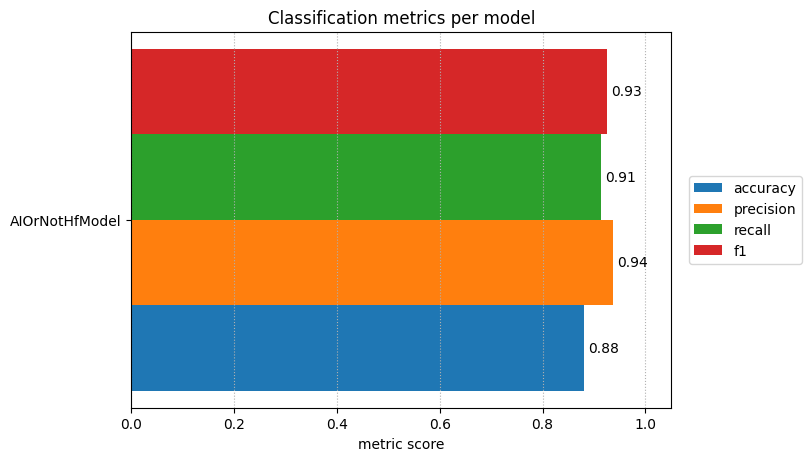

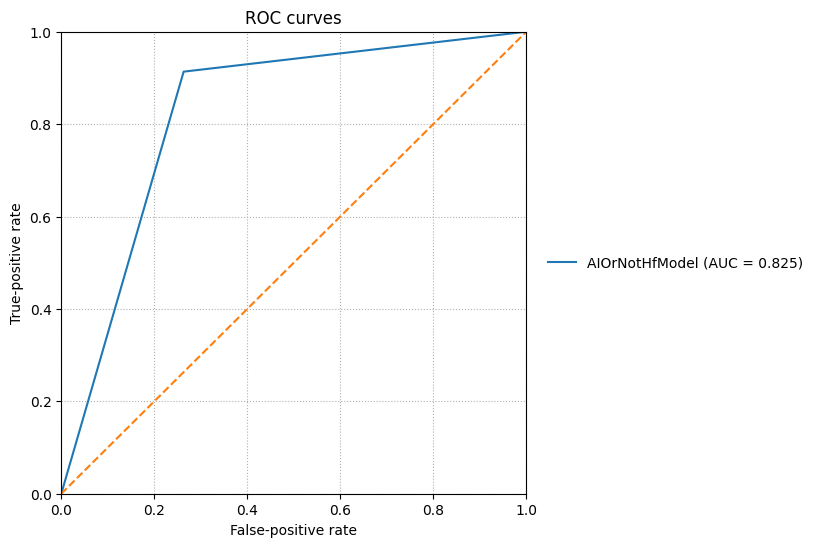

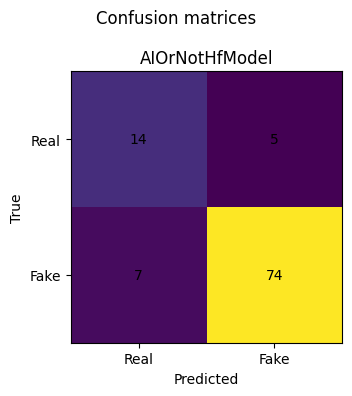

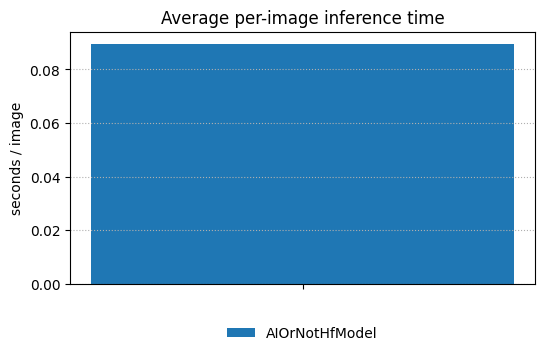

In [ ]:
"""Example usage: sequential eval."""
from src.models.hf_models import (
    AIOrNotHfModel, SDXLDetectorHfModel, AIVSHumanImageDetectorHfModel, DafilabAIImageDetectorHfModel
)

local_models = [AIOrNotHfModel(), SDXLDetectorHfModel(), AIVSHumanImageDetectorHfModel(), DafilabAIImageDetectorHfModel()]
ds = load_dataset(n_samples=200)
stats = evaluate(ds, local_models)
visualize_metrics(stats, local_models)

Loaded 10 random samples.
data/test/archive/fake-v2/2064.jpg fake


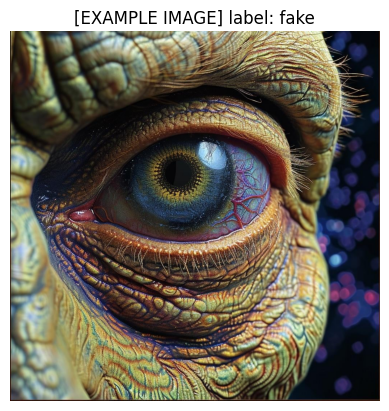

/Users/hxi/.pyenv/versions/3.10.4/lib/python3.10/site-packages/transformers/models/vit/feature_extraction_vit.py:30: FutureWarning: The class ViTFeatureExtractor is deprecated and will be removed in version 5 of Transformers. Please use ViTImageProcessor instead.
  warnings.warn(


[AIOrNotHfModel] Model initialization done.


batch-eval:   0%|          | 0/1 [00:05<?, ?it/s]


ValueError: Invalid image type. Expected either PIL.Image.Image, numpy.ndarray, torch.Tensor, tf.Tensor or jax.ndarray, but got <class 'list'>.

In [6]:
"""Example usage: batch eval."""
from src.utils.data_utils import collate_pil
from src.models.hf_models import (
    AIOrNotHfModel, SDXLDetectorHfModel, AIVSHumanImageDetectorHfModel, DafilabAIImageDetectorHfModel
)

def batch_evaluate(loader: DataLoader, local_models: list[DiscriminatorModel]):
    model_names = [m.__class__.__name__ for m in local_models]

    # containers 
    y_true  = defaultdict(list)
    y_pred  = defaultdict(list)
    y_prob  = defaultdict(list)
    inference_times   = defaultdict(list)

    label2idx = {"real": 0, "fake": 1}

    # evaluation 
    for images, labels in tqdm(loader, total=len(loader), desc="batch-eval"):                 
        for model, name in zip(models, model_names):
            t0 = time.perf_counter()
            outs = model.predict(images, with_probs=True)
            dt  = time.perf_counter() - t0

            preds = [label2idx[o.label] for o in outs]
            probs = [o.probs[1]         for o in outs]   # P(fake)

            y_true[name].extend(labels)
            y_pred[name].extend(preds)
            y_prob[name].extend(probs)
            inference_times[name].append(dt / len(images))   # sec / image
            
    return y_true, y_pred, y_prob, inference_times, model_names


#--------------

ds = load_dataset(n_samples=10)
BATCH_SIZE = 16  
loader = DataLoader(
    ds,
    batch_size=BATCH_SIZE,
    shuffle=False,          
    num_workers=4,          
    collate_fn=collate_pil  
)

models = [AIOrNotHfModel()]
batch_evaluate(loader, ds)